##EXTRACTING THE DATA FROM KAGGLE AND LEARNING IT

In [18]:
import kagglehub
from PIL.TiffImagePlugin import idx
from torch.utils.flop_counter import suffixes

kagglehub.login()

In [19]:
import kagglehub

path = kagglehub.competition_download('cassava-leaf-disease-classification')

print("Path to competition:", path)

Path to competition: C:\Users\Rushabh\.cache\kagglehub\competitions\cassava-leaf-disease-classification


In [20]:
import os

print(os.listdir("data"))

['raw']


In [21]:
import os
import zipfile

zip_path = r"A:\DataSet\cassava-leaf-disease-classification.zip"
exact_path =  r"C:\Users\Rushabh\PycharmProjects\Image Classification (CNN)\data\raw"

os.makedirs(exact_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(exact_path)
print("Extraxtion Completed")

Extraxtion Completed


In [22]:
import os

raw_data = r"C:\Users\Rushabh\PycharmProjects\Image Classification (CNN)\data\raw"

for item in os.listdir(raw_data):
    path = os.path.join(raw_data, item)
    if os.path.isdir(path):
        print(f"[Folder]: {item}")
    else:
        print(f"[File]: {item}")

[File]: label_num_to_disease_map.json
[File]: sample_submission.csv
[Folder]: test_images
[Folder]: test_tfrecords
[File]: train.csv
[Folder]: train_images
[Folder]: train_tfrecords


In [23]:
import csv
import os

train_csv = os.path.join(raw_data, "train.csv")

with open(train_csv, "r", newline="", encoding="utf-8") as f:
    reader = csv.reader(f)

    rows = list(reader)

print("Columns:", rows[0])
print("First 5 rows:")

for row in rows[1:6]:
    print(row)

print("Total rows:", len(rows) - 1)

Columns: ['image_id', 'label']
First 5 rows:
['1000015157.jpg', '0']
['1000201771.jpg', '3']
['100042118.jpg', '1']
['1000723321.jpg', '1']
['1000812911.jpg', '3']
Total rows: 21397


In [24]:
import json
import os

map_path = os.path.join(raw_data, "label_num_to_disease_map.json")

with open(map_path, "r", encoding="utf-8") as f:
    disease_map = json.load(f)

print(disease_map)

{'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}


In [25]:
print(os.listdir("data/raw/train_images"))

['1000015157.jpg', '1000201771.jpg', '100042118.jpg', '1000723321.jpg', '1000812911.jpg', '1000837476.jpg', '1000910826.jpg', '1001320321.jpg', '1001723730.jpg', '1001742395.jpg', '1001749118.jpg', '100204014.jpg', '1002088496.jpg', '1002255315.jpg', '1002394761.jpg', '1003218714.jpg', '1003298598.jpg', '1003442061.jpg', '1003888281.jpg', '1003987001.jpg', '1004105566.jpg', '1004163647.jpg', '1004389140.jpg', '1004672608.jpg', '100472565.jpg', '1004826518.jpg', '1004881261.jpg', '1005138819.jpg', '1005200906.jpg', '100533489.jpg', '100560400.jpg', '1005695738.jpg', '1005739807.jpg', '100609661.jpg', '1007196516.jpg', '1007246985.jpg', '100731318.jpg', '1007533812.jpg', '1007700625.jpg', '1007891044.jpg', '1008126487.jpg', '1008142548.jpg', '1008244905.jpg', '1008284502.jpg', '1008532311.jpg', '1009037539.jpg', '1009049118.jpg', '1009126931.jpg', '1009148537.jpg', '1009268848.jpg', '1009322597.jpg', '1009361983.jpg', '1009431532.jpg', '1009441020.jpg', '1009462599.jpg', '1009489704.jpg'

In [26]:
file_1 = os.listdir("data/raw/train_images")
c = 0
nc = 0
for row in rows:
    if row[0] in file_1:
        print(row)
        c = c + 1
    else:
        nc = nc + 1
        print("File Not Found")
print("Total File found:", c)
print("Total File nor found:", nc)

File Not Found
['1000015157.jpg', '0']
['1000201771.jpg', '3']
['100042118.jpg', '1']
['1000723321.jpg', '1']
['1000812911.jpg', '3']
['1000837476.jpg', '3']
['1000910826.jpg', '2']
['1001320321.jpg', '0']
['1001723730.jpg', '4']
['1001742395.jpg', '3']
['1001749118.jpg', '3']
['100204014.jpg', '3']
['1002088496.jpg', '1']
['1002255315.jpg', '3']
['1002394761.jpg', '3']
['1003218714.jpg', '2']
['1003298598.jpg', '3']
['1003442061.jpg', '4']
['1003888281.jpg', '0']
['1003987001.jpg', '3']
['1004105566.jpg', '3']
['1004163647.jpg', '3']
['1004389140.jpg', '1']
['1004672608.jpg', '3']
['100472565.jpg', '2']
['1004826518.jpg', '2']
['1004881261.jpg', '3']
['1005138819.jpg', '3']
['1005200906.jpg', '2']
['100533489.jpg', '2']
['100560400.jpg', '4']
['1005695738.jpg', '3']
['1005739807.jpg', '3']
['100609661.jpg', '3']
['1007196516.jpg', '3']
['1007246985.jpg', '3']
['100731318.jpg', '3']
['1007533812.jpg', '3']
['1007700625.jpg', '3']
['1007891044.jpg', '3']
['1008126487.jpg', '3']
['100814

In [27]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Interpreter:", sys.executable)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Interpreter: C:\Users\Rushabh\AppData\Local\Programs\Python\Python312\python.exe
NumPy: 2.4.6
Pandas: 3.0.3


In [28]:
import torch
print(torch.__version__)

2.13.0+cpu


In [29]:
df = pd.read_csv(train_csv)
print(df.head())

         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3


In [30]:
print("%" * 69)
print(df.shape)
print("%" * 69)
print(df.columns)
print("%" * 69)
print(df.value_counts("label"))
print("%" * 69)
print(df.describe())
print("%" * 69)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
(21397, 2)
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Index(['image_id', 'label'], dtype='str')
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
label
3    13158
4     2577
2     2386
1     2189
0     1087
Name: count, dtype: int64
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
              label
count  21397.000000
mean       2.651914
std        0.988565
min        0.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


##EVALUATING IMAGES

In [31]:
from PIL import Image
img = Image.open("data/raw/train_images/1000015157.jpg")
img.show()

In [32]:
print(img.size)
print(img.mode)
print(img.format)

(800, 600)
RGB
JPEG


In [33]:
from PIL import Image
import os
import pandas as pd

widths = []
heights = []
modes = []

for filename in df["image_id"]:

    image_path = os.path.join("data/raw/train_images", filename)

    img = Image.open(image_path)

    width, height = img.size

    widths.append(width)
    heights.append(height)
    modes.append(img.mode)

df["width"] = widths
df["height"] = heights
df["mode"] = modes

In [34]:
unique_dimensions = df[["width", "height"]].drop_duplicates()

print(unique_dimensions)

print(df.value_counts("mode"))

   width  height
0    800     600
mode
RGB    21397
Name: count, dtype: int64


##Display one actual image from each of the 5 classes

##Lable = 0

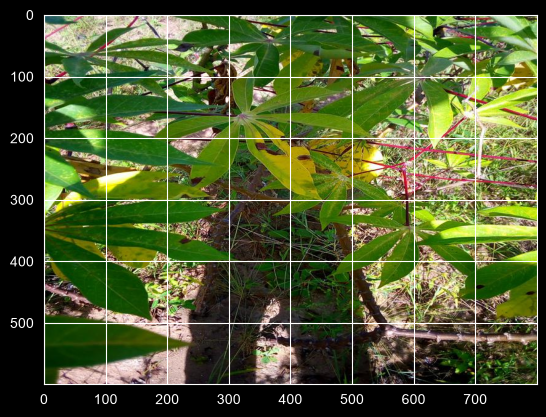

In [35]:
import matplotlib.pyplot as plt


class_0 = df[df["label"] == 0]
filename = class_0["image_id"].iloc[0]
image_path = os.path.join("data/raw/train_images", filename)
img = Image.open(image_path)
plt.imshow(img)
#plt.axis("off")
plt.show()


##Label = 1

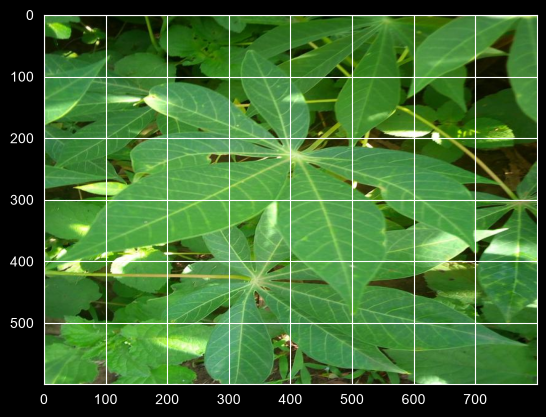

In [36]:
import matplotlib.pyplot as plt

class_1 = df[df["label"] == 1]
filename = class_1["image_id"].iloc[0]
image_path = os.path.join("data/raw/train_images", filename)
img = Image.open(image_path)
plt.imshow(img)

##Label = 2

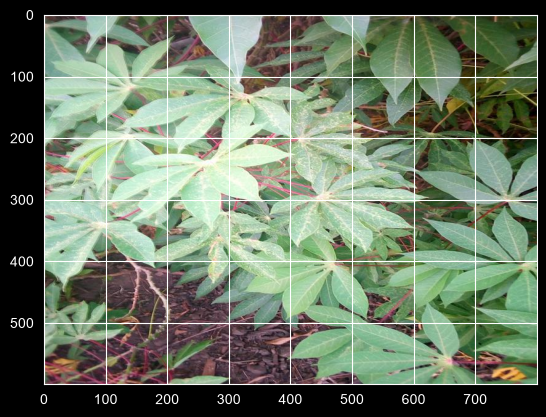

In [37]:
class_2 = df[df["label"] == 2]
filename = class_2["image_id"].iloc[0]
image_path = os.path.join("data/raw/train_images", filename)
img = Image.open(image_path)
plt.imshow(img)


##Label = 4

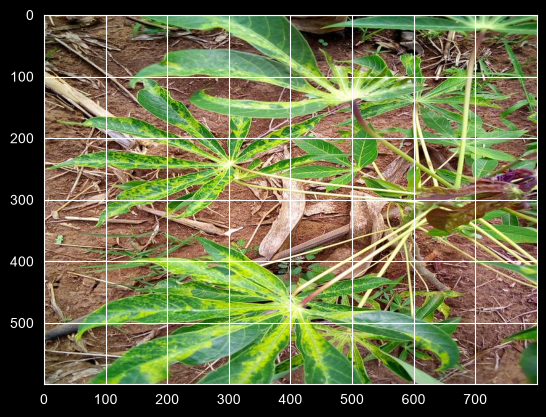

In [38]:
class_3 = df[df["label"] == 3]
filename =  class_3["image_id"].iloc[0]
image_path = os.path.join("data/raw/train_images", filename)
img = Image.open(image_path)
plt.imshow(img)


##Label = 4

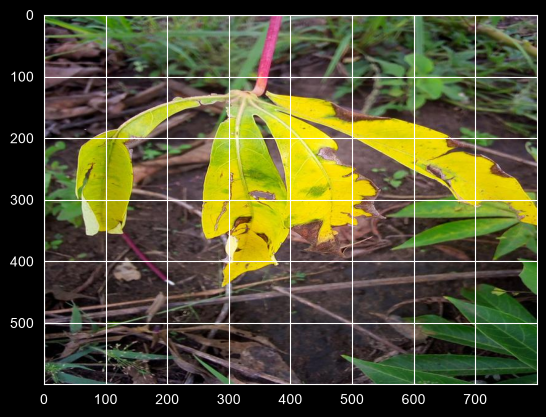

In [39]:
class_4 = df[df["label"] == 4]
filename = class_4["image_id"].iloc[0]
image_path = os.path.join("data/raw/train_images", filename)
img = Image.open(image_path)
plt.imshow(img)

In this phase, I explored the Cassava Leaf Disease Classification dataset containing 21,397 images across five classes using Pandas, Pillow, and Matplotlib. I analyzed the class distribution and identified class imbalance, with Cassava Mosaic Disease (Class 3) accounting for approximately 61.49% of the dataset. I inspected image properties and confirmed that all 21,397 images have consistent dimensions of 800 × 600 pixels and RGB color mode. I also visualized sample images from all five classes to understand their visual characteristics. This analysis provided an understanding of the dataset and established the foundation for the next phase: building the PyTorch data pipeline.

##SPLITING INTO TRAINING SET AND TESTING SET

In [40]:
import sklearn
from sklearn.model_selection import train_test_split

X = df["image_id"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)


In [41]:
print("The Shape of X_train is: ",X_train.shape)
print("The Shape of X_test is: ",X_test.shape)
print("The Shape of y_train is: ",y_train.shape)
print("The Shape of y_test is: ",y_test.shape)

The Shape of X_train is:  (17117,)
The Shape of X_test is:  (4280,)
The Shape of y_train is:  (17117,)
The Shape of y_test is:  (4280,)


In [42]:
print(y_train.value_counts(normalize=True) * 100)
print("%" * 70)
print(y_test.value_counts(normalize=True) * 100)

label
3    61.494421
4    12.040661
2    11.152655
1    10.229596
0     5.082666
Name: proportion, dtype: float64
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
label
3    61.495327
4    12.056075
2    11.144860
1    10.233645
0     5.070093
Name: proportion, dtype: float64


##Converting To tensor

In [44]:
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

Loading one image

In [47]:
img_path = os.path.join("data/raw", "train_images",X_train.iloc[0])
img = Image.open(img_path).convert("RGB")

In [48]:
transforms = transforms.ToTensor()
img_transformed = transforms(img)
print(img_transformed.shape)

torch.Size([3, 600, 800])


In [62]:
from torch.utils.data import Dataset

class CassavaDataset(Dataset):
    def __init__(self,image_path, label, transform=None):
        super().__init__()
        self.image_path = image_path
        self.label = label
        self.transform = transform
    def __len__(self):
        return len(self.image_path)

    def __getitem__(self, idx):
        filename = self.image_path.iloc[idx]
        label = self.label.iloc[idx]
        img_path = os.path.join("data/raw/train_images", filename)
        img = Image.open(image_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label




In [63]:
from torchvision import transforms

transform = transforms.ToTensor()


train_data_set = CassavaDataset(
    image_path=X_train,
    label=y_train,
    transform=transform
)

test_data_set = CassavaDataset(
    image_path=X_test,
    label = y_test,
    transform=transform
)

print("Length of Training samples: ", len(train_data_set))
print("Length of Test samples: ", len(test_data_set))



Length of Training samples:  17117
Length of Test samples:  4280


In [66]:
img, label = train_data_set[0]


In [67]:
print("Image Shape:", img.shape)
print("Label Shape:", label.shape)
print("Image dtype:", img.dtype)
print("Label dtype:", label.dtype)

Image Shape: torch.Size([3, 600, 800])
Label Shape: ()
Image dtype: torch.float32
Label dtype: int64


In [68]:
import torch
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
)


test_dataloader = DataLoader(
    dataset=test_data_set,
    batch_size=BATCH_SIZE,
    shuffle = False
)

In [69]:
train_feature, train_lables = next(iter(train_dataloader))

print("Image batch shape: ",train_feature.shape)
print("Image data type: ", train_feature.dtype)
print("Label batch image: ",train_lables.shape)
print("Label daya type: ",train_lables.dtype)


Image batch shape:  torch.Size([32, 3, 600, 800])
Image data type:  torch.float32
Label batch image:  torch.Size([32])
Label daya type:  torch.int64


## Visualize a batch

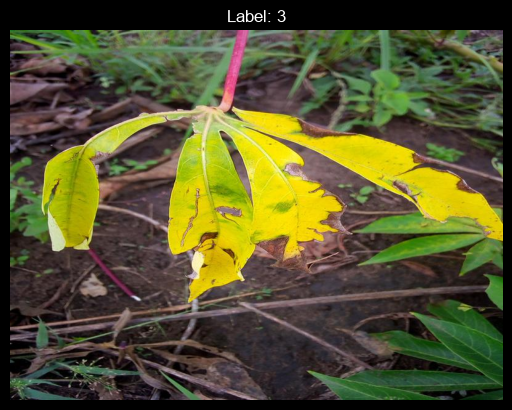

In [70]:
import matplotlib.pyplot as plt

img, label = train_feature[0], train_lables[0]

plt.imshow(img.permute(1, 2, 0))
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

##Resizing the image for less memory

In [85]:
img_path = os.path.join("data/raw", "train_images", X_train.iloc[0])

img = Image.open(img_path).convert("RGB")

img = image_transform(img)

print("After resizing shape:", img.shape)

After resizing shape: torch.Size([3, 224, 224])


##Normalization

In [ ]:

for filename in X_train:
    img = os.path.join("data/raw", "train_images", filename)
    img = Image.open(img).convert("RGB")
    img = img_transformed(img)